## <span style="color:blue">Regression Modeling for Temperature Forecasting</span> 

### Research Interest - 

In the realm of meteorological science, the accurate prediction of temperature stands as a pivotal endeavor with multifaceted implications. Predicting temperatures is crucial in every facet of life from aiding a common man's daily activities to complex scenarios such as a military mission.The challenge lies in harnessing the vast repository of weather data to develop robust regression models that can reliably forecast temperatures. This project seeks to address the intricate nuances of temperature prediction by employing suitable regression techniques, thereby contributing to the refinement of weather forecasting methodologies.

### Goal - 
The objective of this project is to not only employ a variety of regression techniques to predict temperatures of Szeged,Hungary but also to understand the past trends of various features that helps in determining temperature.

### Objectives - 

#### 1. **Analysis of Weather Data:**

Objective: Explore and understand the patterns, trends, and relationships within the weather dataset.

Hypothesis: The weather data will exhibit seasonal variations, and certain weather conditions will strongly correlate with temperature changes.

**2. Developing Regression Models:**

Objective: Build predictive models to estimate temperature based on various weather features.

Hypothesis:  Multiple linear regression models can effectively capture the relationships between weather variables and temperature.

**3. Evaluating Model Performance:**

Objective: Assess the accuracy and generalization capability of the regression models.

Hypothesis: The chosen regression model will demonstrate good performance metrics such as low Mean Squared Error and high R-squared.

**4.Comparative Analysis Between Various Regression Models:**

Objective: Compare different regression techniques to identify the most suitable model for temperature prediction.

Hypothesis: Regularized regression models (e.g., Ridge, Lasso) will outperform basic linear regression due to their ability to handle multicollinearity.

**5. Model Interpretability - Understanding Key Variables Influencing Temperature:**

Objective: Identify and interpret the key variables that significantly influence temperature predictions.

Hypothesis:  Certain weather features such as humidity, wind speed, and precipitation type will have a substantial impact on temperature, influencing the overall model interpretability.

### Significance of the Project -

The significance of predicting temperature transcends mere meteorological curiosity. Its implications are woven into everyday life. Accurate predictions empower individuals to plan travel, schedule events, and organize outdoor activities with minimal disruptions. This project goes beyond technicalities of regression, offering pragmatic value by enhancing the efficiency of daily planning in simple as well as crucial tasks through precise temperature forecasting.

### Theoretical background of the topic - 

Predicting temperature using regression techniques involves understanding meteorological factors (precipitation, pressure, humidity) and technical methodologies of data preparation and modelling. Understanding both these factors is crucial to build a robust model. The Weather data of Szeged, sourced meticulously from Apple's Dark Sky API spanning the decade from 2006 to 2016, serves as the dataset for this project. 

## <span style="color:maroon">3. Data Description</span> 

The data for this project is Weather in Szeged 2006 - 2016 sourced from Kaggle. Originally, the data has been collected through Apple's Dark Sky API spanning the decade from 2006 to 2016.

The data has 12 features and 96453 rows. 
Below is a short description of the 12 features in the dataset.

| Feature               | Data Type  | Description                                                             |
|:----------------------:|:----------:|:-----------------------------------------------------------------------:|
| Formatted Date        |   object   | The date along with timestamp on which the weather conditions were observed.                   |
| Summary               |   object   | The summary of the weather at the point of time (e.g., Cloudy, Clear, Drizzle).                 |
| Precipitation Type    |   object   | Indicates if it's rain or snow.                                           |
| Temperature           |  float64   | Temperature in degrees Celsius.                                           |
| Apparent Temperature  |  float64   | Apparent Temperature in degrees Celsius (Feels like temperature).        |
| Humidity              |  float64   | Humidity levels in the air.                                               |
| Wind Speed (km/h)     |  float64   | Speed of the wind recorded in km/h.                                       |
| Wind Bearing (degrees)|  float64   | Direction of the wind measured in degrees.                                |
| Visibility (km)       |  float64   | The greatest distance under given weather conditions to which it is possible to see without any tools measured in km. |
| Cloud Cover           |  float64   | The range of the clouds.                                                  |
| Pressure              |  float64   | The weight of the air measured in millibars.                             |
| Daily Summary         |  float64   | Short summary of the weather condition for that particular day.          |

- **Numerical Columns**  -  'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed(km/h)', 'Wind Bearing (degrees)','Visibility (km)', 'Pressure (millibars)' - All are continuous.
- **Categorical Columns** -  'Formatted Date', 'Precip Type','Summary','Daily Summary' - All are Nominal except Precip Type which is ordinal.

Link to the dataset - https://www.kaggle.com/datasets/budincsevity/szeged-weather/data

The first five rows of the dataset -

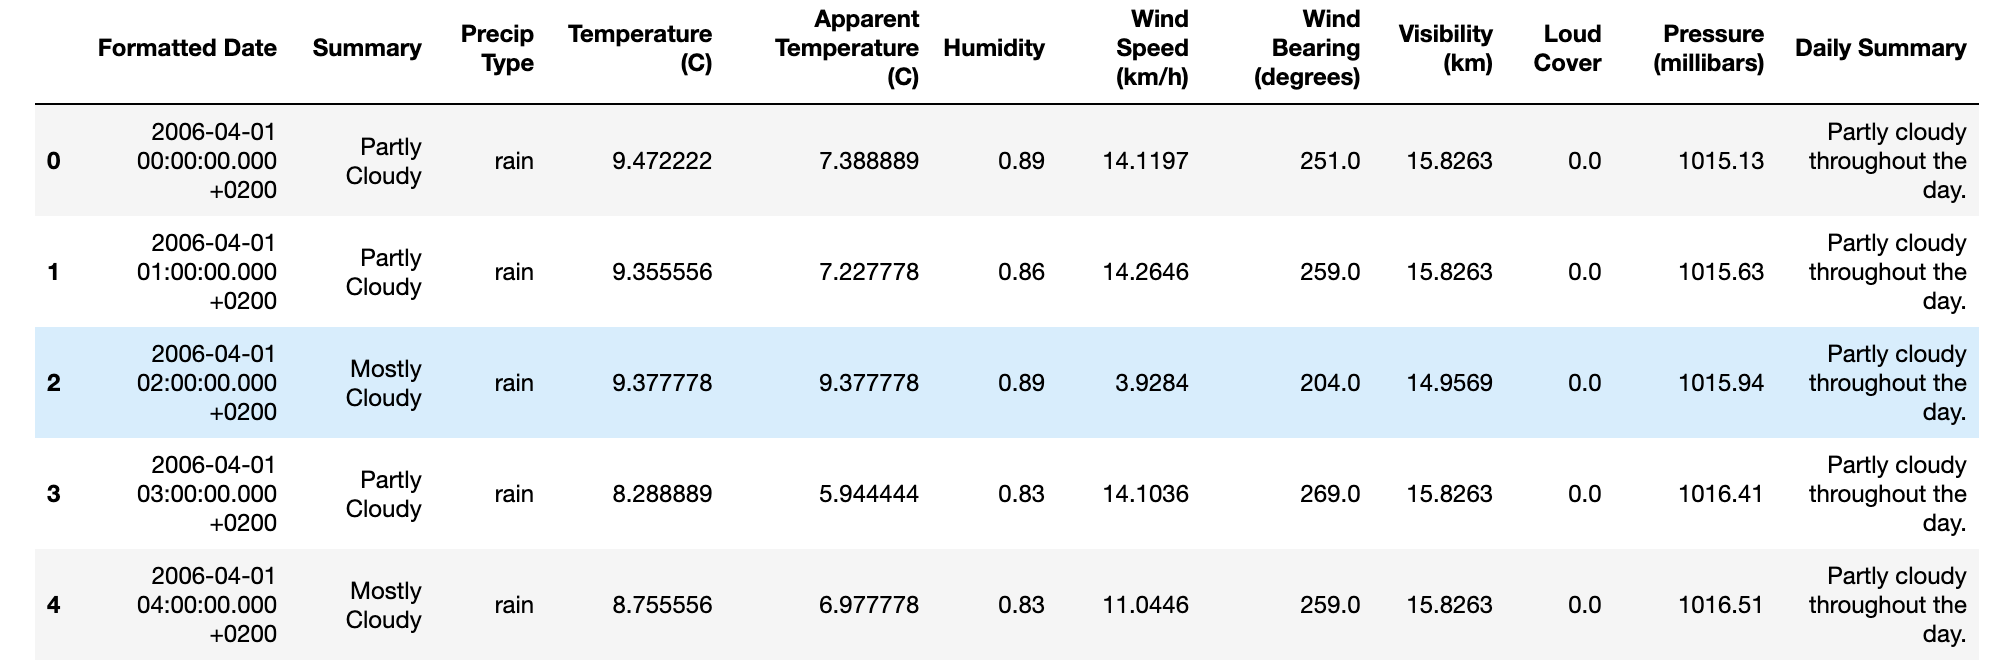


### 3.1 Preprocessing

### **Missing Values :**

The only column with outliers is "Precip Type," which had 517 missing values. To handle this, I filled the missing values in the "Precip Type" column with the mode, which is "rain." No other column had missing values.

### **Outliers :**

Boxplots were employed to identify outliers, revealing a noteworthy presence in the "Wind Speed (km/h)" column. However, upon quantifying outliers using the Interquartile Range (IQR) method, it was discovered that there were 4400 outliers in Pressure (millibars), which is more than the 3028 outliers in the "Wind Speed (km/h)" column but this wasn't evident in the visualization. Notably, "Wind Bearing" and "Visibility" columns exhibited an absence of outliers, while the remaining columns demonstrated a minimal count of outlier values. As a strategic measure to enhance model performance, these outliers have been systematically removed from the dataset.

### **Data Quality Issues :**

1. The "Summary" column in the dataset presented diverse values that were subsequently categorized into distinct groups. The identified categories encompass Cloudy, Clear/Dry, Foggy, Breezy, Windy, Rain, and Humid, each exhibiting a specific distribution as depicted in the bar chart below. Notably, the prevalent weather condition in Szeged during the period spanning from 2006 to 2016 has predominantly been characterized as Cloudy.

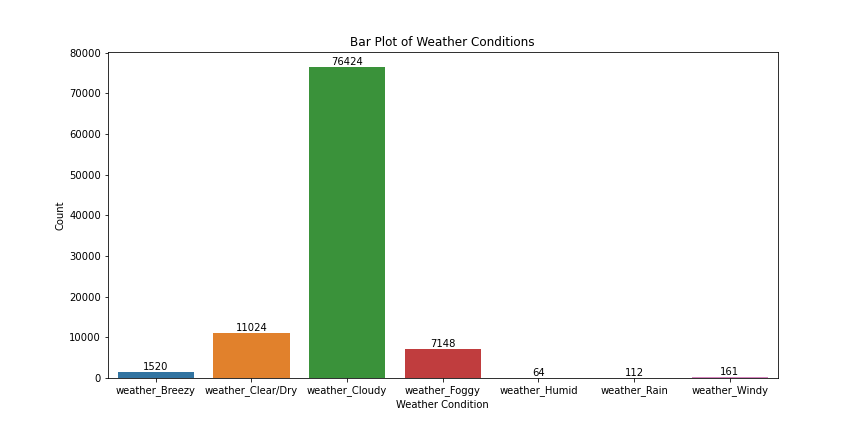

2. The "Daily Summary" column was removed from the dataset as its observations were already encompassed within the "Summary" column, albeit with additional data points.

3. The formatted date column has been dropped as the goal is to trying to predict temperature irrespective of the date time.

4. On performing summary statistics, it was observed that the Cloud cover column had all values as zero, and therefore has been dropped as it doesn't provide any significant information.

4. Presented below is a correlation matrix of all numerical columns in the dataset. A notable observation from this matrix is the exceptionally high correlation of 0.99 between the "Temperature" and "Apparent Temperature" columns. Consequently, the "Apparent Temperature" column has been dropped, given its redundancy as it merely represents the perceived temperature rather than the actual temperature. Additionally, the correlation analysis reveals a significant negative correlation between humidity and temperature, as well as a positive correlation between visibility and temperature.

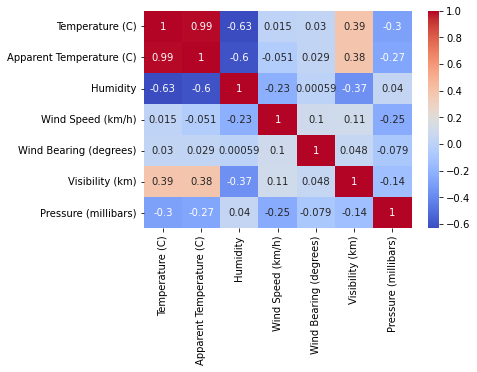


### **Data Transformation**

1. The Summary column which is an ordinal data column has been transformed to a range between 0 and 1 using One Hot encoding.
2. In the Precip Type column, the two values rain and snow has been replaced with 1 and 0 respectively. 
3. The rest of the columns have been transformed using sklearn's Standard Scaler such that their mean is 0 and standard deviation is 1.

**The first five rows of common data that will be used for analysis and modelling is -**
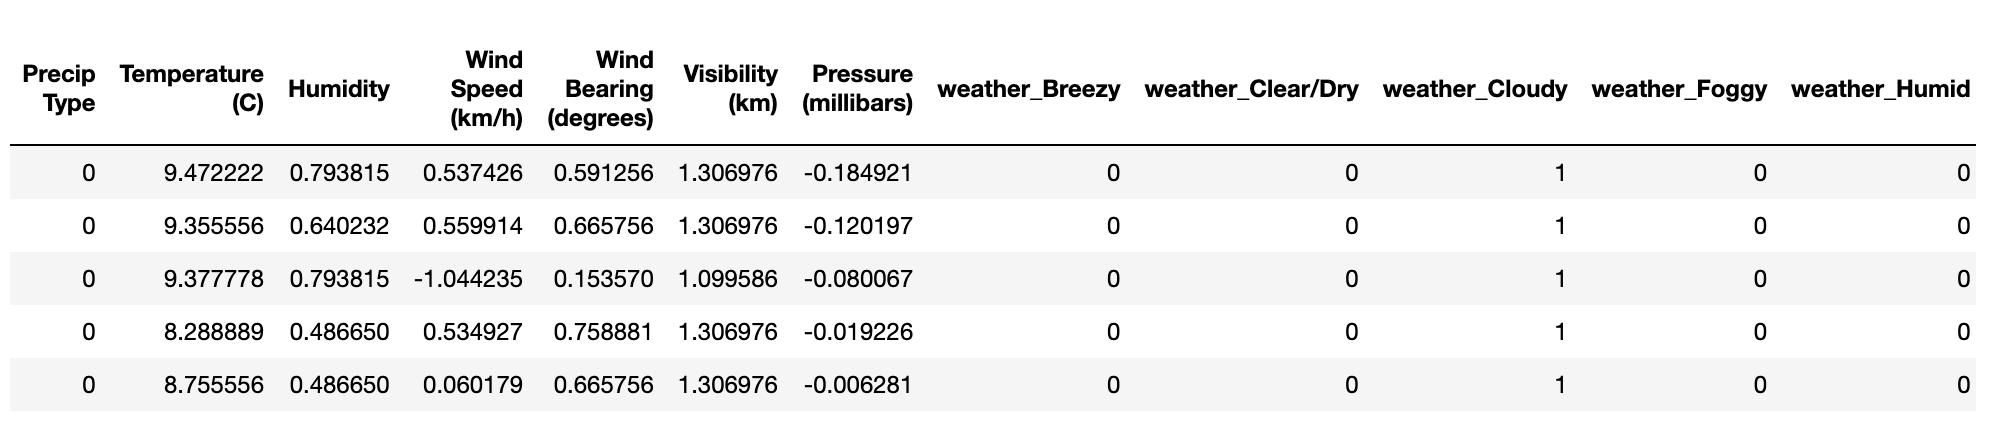


### **Exploratory Data Analysis**

The histograms below for each numerical column, gives an idea of how the data is distributed.
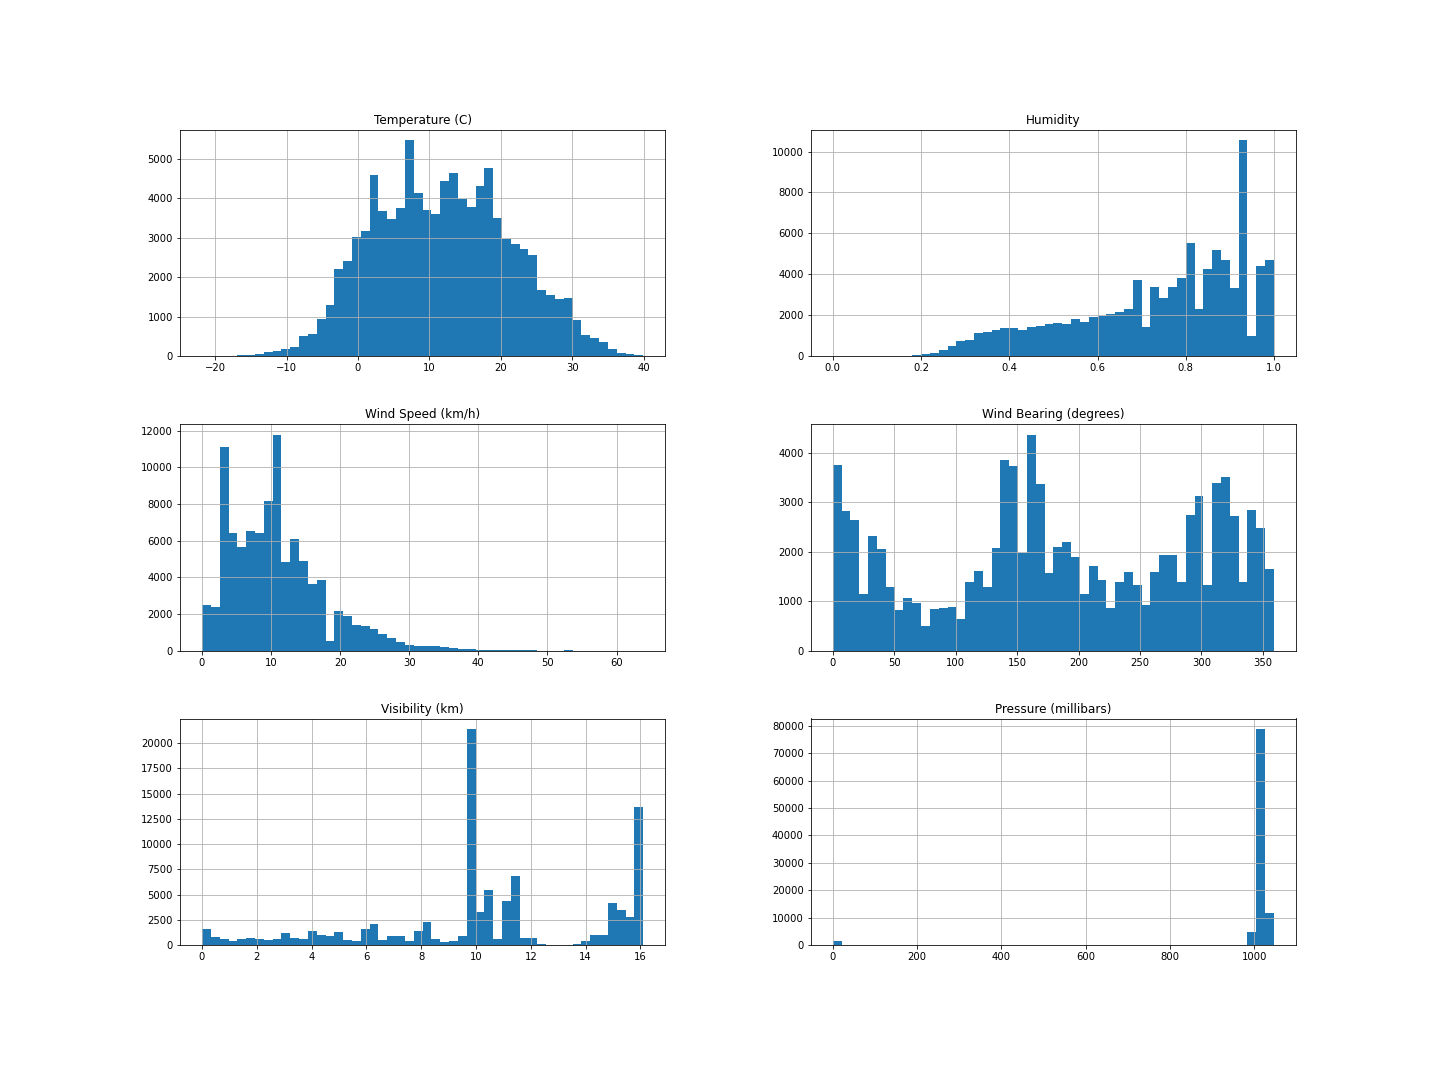


The violin plot illustrates the temperature distribution for Rain(0) and Snow(1). It can be observed, in case of Snow, temperatures predominantly fall below the freezing point, reflecting the expected lower temperatures associated with snowy conditions. Conversely, for Rain, the plot reveals an average temperature of approximately 15 degrees Celsius, with the potential for temperatures reaching up to 40 degrees Celsius. This distinction in temperature ranges aligns with the typical meteorological expectations for these precipitation types in real-life scenarios.
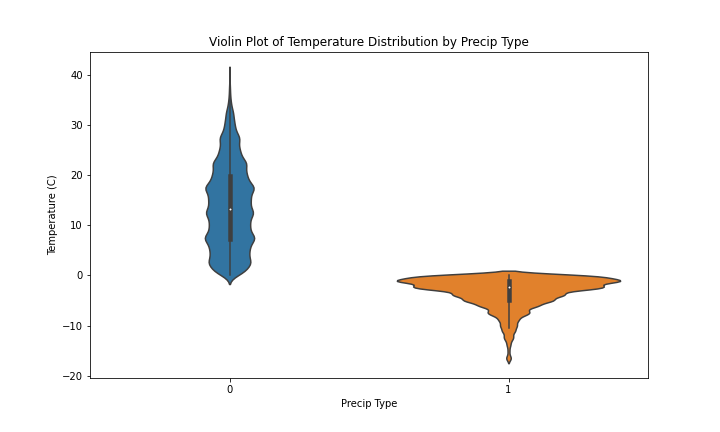

The below visualization,which is a pair plot with a regression line, each scatterplot shows the relationship between the dependent variable(Temperature(C)) and one of the independent variables. The features "Wind Speed(km/h)" and "Wind Bearing (degrees)" have more variability in the data because the data is scattered widely around the line. Features "Humidity", "Visibility(km)", "Pressure(millibars)" on the other hand demonstrate variability but they also have a steep increase or steep decrease indicating a linear relationship with the target variable.

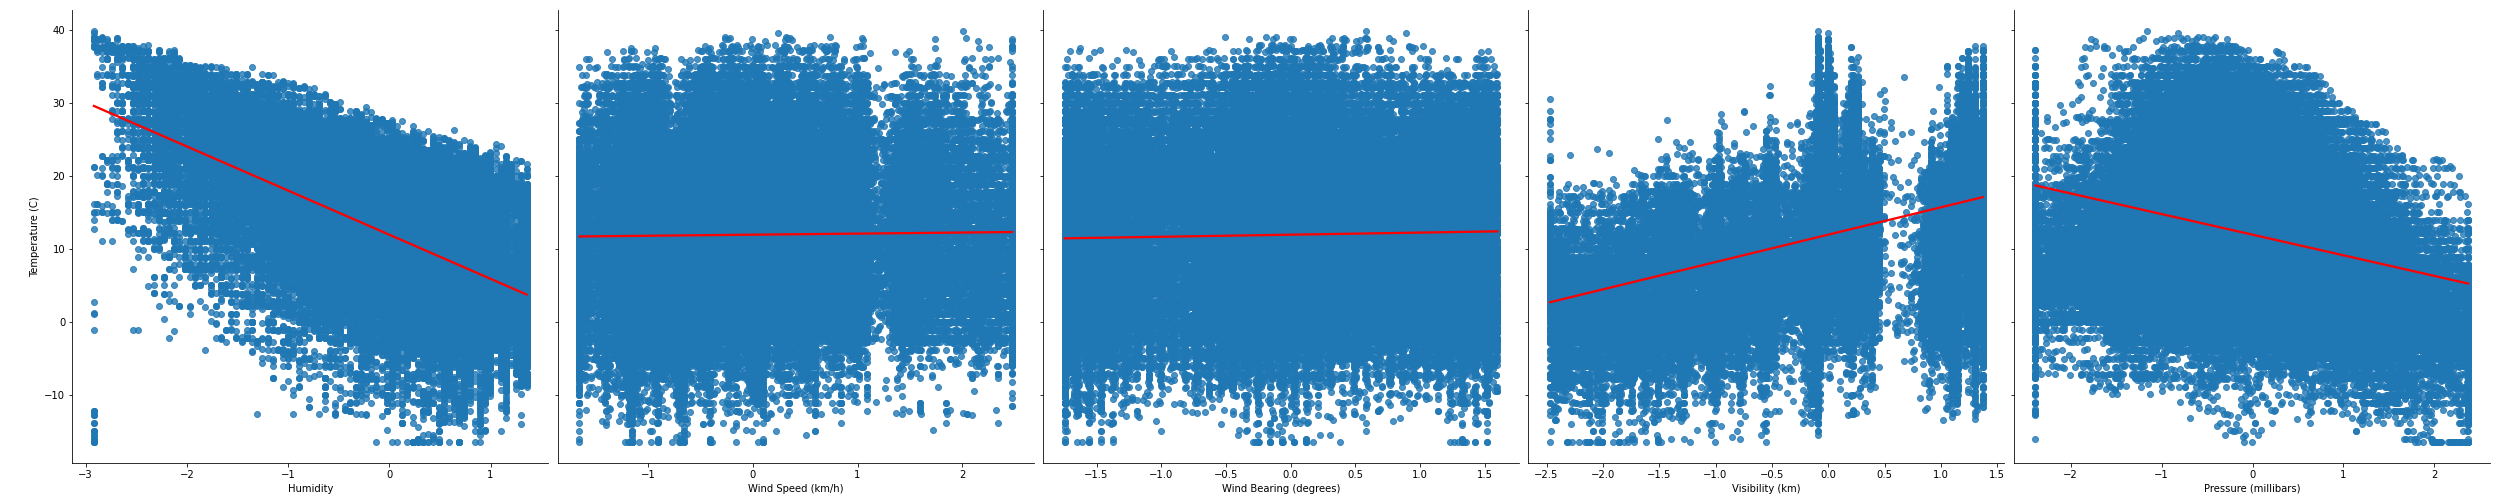

### **Data Split**

After preprocesing as demonstrated above, the dataset for the regression models was split into training and testing sets in a 70:30 ratio. The training set has 67,517 rows, and the testing set has 28,936 rows.

## <span style="color:maroon">4.Methodology</span> 

The regression approach I followed to predict temperature from the given features is **Multiple Linear Regression**. Starting with the assumption that Multiple Linear Regression is my best model. I have also applied regularization approaches Lasso, Ridge, Elastic Net on the data to further improve the model performance.

### **Linear Regression** -

- Presumes a linear association between the target variable and input features.
- Assumes the independence of observations, implying that each data point is unrelated to others.
- The pair plots above depicted a linear trend between each independent feature and the dependent variable, temperature. 
- Additionally, the correlation matrix depicts the minimal interrelation among independent features. Consequently, - Linear Regression emerges as the preferred model for temperature prediction, given the apparent linearity in the pair plots and the observed lack of substantial correlation among independent features.

Other assumptions of Multiple linear regression :

- __Homoscedasticity:__ The variance of errors/residuals should be constant across all levels of predictors; there should be no systematic patterns in residuals as predictors change.
- __Normality:__ The errors/residuals follow a normal distribution; this assumption ensures reliable statistical inference using techniques like hypothesis testing or confidence intervals.
- __No Multicollinearity:__ Independent variables should not exhibit high correlation with each other; high multicollinearity can lead to unstable estimates of coefficients and difficulty interpreting their individual effects.
- __No Endogeneity:__ There shouldn't be any reverse causality or feedback loops between predictors and response variables; otherwise, it becomes challenging to establish cause-and-effect relationships accurately.

**Linear Regression has been implemented using sklearn's Linear Regression Model. The model has performed fairly well with Mean Squared Error as 32.2561, R-squared Score as 0.6462, Root Mean Squared Error as 5.6794**

### **Checking for Model assumptions** - 

**Linearity** - This assumption can be tested by plotting the observed versus predicted values or residuals versus predicted values. A random scatter indicates that this assumption is met. 

**Independence** - Durbin-Watson test can be used to check this assumption which reports a test statistic between 0 and 4. Test statistic around 2 suggests no autocorrelation, less than 1 or greater than 3 suggest positive or negative autocorrelation respectively.The Durbin-Watson test statistic obtained was 0.1617. This suggessts that there is a positive autocorrelation.

**Homoscedasticity** - This assumption can also be checked by plotting residuals versus predicted values as above for linearity check, a random scatter indicates homoscedasticity while any pattern (funnel shape etc.) indicates heteroscedasticity i.e., violation of this assumption. As observed in the visualization below, the values are a random scatter indicating Homoscedasticity.

**Normality** - Q-Q plot compares quantiles of observed data against theoretical quantiles expected under normal distribution. Points lying on straight line in Q-Q plot indicate that data follows normal distribution.

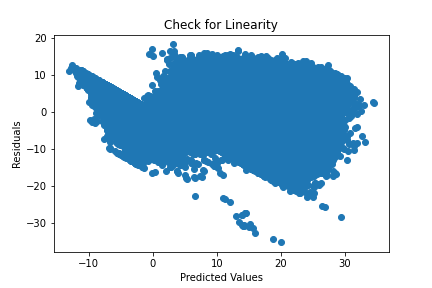
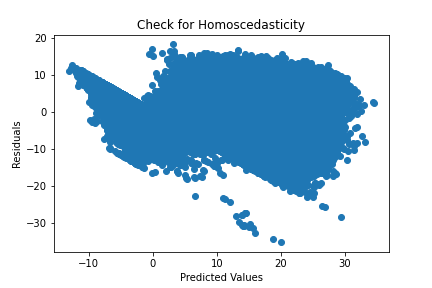
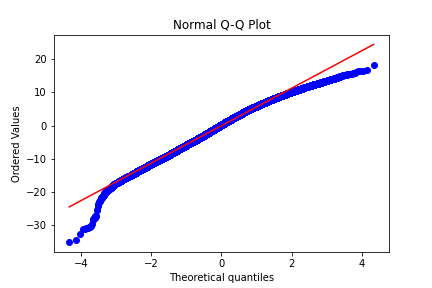

**No Multicollinearity** - Variance Inflation Factor (VIF) is commonly used to detect multicollinearity.VIF starts at 1 and has no upper limit. A general rule of thumb is that VIF larger than 5 means high correlation and hence multicollinearity between your variables. It can be observed from below that all the VIF values are less than 1.7 indicating there is no high corrrelation between variables.

| Feature                | VIF       |
|------------------------|-----------|
| Precip Type            | 1.221156  |
| Humidity               | 1.258714  |
| Wind Speed (km/h)      | 1.284112  |
| Wind Bearing (degrees) | 1.017362  |
| Visibility (km)        | 1.693814  |
| Pressure (millibars)   | 1.174013  |
| weather_Breezy         | 1.117715  |
| weather_Clear/Dry      | 1.061153  |
| weather_Cloudy         | 1.130696  |
| weather_Foggy          | 1.594858  |
| weather_Humid          | 1.000545  |
| weather_Rain           | 1.002215  |
| weather_Windy          | 1.012870  |


### **Lasso Regression** -

- Lasso Regression is a regression approach in which feature selection holds paramount importance, effectively driving irrelevant features towards zero. 
-  In the context of this project, from the correlation visualization above it can be infered that "Wind Speed,"  exhibits negligible correlation or relationship with the target variable, Temperature. 
-  Lasso in such cases can reduce the complexity of the model by making these features to zero.

### **Ridge Regression** - 
- Ridge Regression addresses multicollinearity in the dataset, offering a solution to prevent overfitting, a crucial consideration in weather prediction based on historical data.
- In Ridge, regularization term is added to control complexity by penalizing large coefficients thus increasing bias but reducing variance leading more stable models especially when dealing with multicollinearity or large number features.
- An overfitted model might look at every single day in history and try to find a pattern that perfectly fits all those days – even if some were unusually hot due to rare events like heatwaves.
- The model might then predict inaccurately high temperatures for tomorrow because it was influenced too much by these outliers instead of recognizing broader patterns across seasons or years. 
- However, Ridge Regression is employed in this case to handle this issue.

### **Elastic Net Regression** - 
- Elastic Net combines both Ridge and Lasso techniques: It adds both absolute value of magnitude (like lasso) as well as squares of magnitude (like ridge) into penalty term. 
- In the context of this project, as mentioned above for Lasso and Ridge, the Elastic Net model can combine both the techniques and tend to provide better results.

### **Model Comparison**

| Model          | Mean Squared Error | R-squared Score | Root Mean Squared Error |
| -------------- | ------------------- | --------------- | ------------------------ |
| Linear         | 32.2561             | 0.6462          | 5.6794                   |
| Ridge          | 32.2561             | 0.6462          | 5.6794                   |
| Lasso          | 32.5619             | 0.6428          | 5.7063                   |
| Elasticnet     | 32.4182             | 0.6444          | 5.6937                   |

The model results suggest that the performance of all the models is very similar, however with slight differences.
However, Linear and Ridge exhibited a lower Mean Squared Error and higher R-squared score indicating potential chances to be the best model in this case.

### **Model Improvement**
However, before finalizing on the better model, model improvement techniques like Cross Validation has been implemented and below are the best parameters obtained for each of the model. The best parameters mentioned below is obtained through Grid Search Cross Validation.

#### ***Lasso Model***:
- Best Parameters: {'alpha': 0.1, 'max_iter': 1000}

#### ***Ridge Model***:
- Best Parameters: {'alpha': 0.1, 'max_iter': 1000}

#### ***Elastic Net Model***:
- Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.9, 'max_iter': 1000}


The below visualizations depict how cross validation affected the R^2 scores and how well it performed on the test set. The R^2 scores are obtained through LassoCV, RidgeCV, ElasticnetCV.

The cross-validated R^2 score is obtained through cross-validation, which involves splitting the dataset into multiple subsets (folds). The model is trained on some folds and tested on others, and this process is repeated for each fold.The R^2 score for each fold is calculated, and the cross-validated R^2 score is the average of these scores.It provides an estimate of how well the model generalizes to unseen data. Cross-validation helps to assess the model's performance across different subsets of the data, reducing the risk of overfitting to a specific training-test split.

The test R^2 score is calculated on a separate, held-out test set that the model has not seen during training. This set is reserved specifically for evaluating the model's performance after it has been trained.
The test R^2 score provides an indication of how well the model is expected to perform on new, unseen data.
It helps to assess how well the model generalizes beyond the training data and provides insights into its real-world predictive performance.

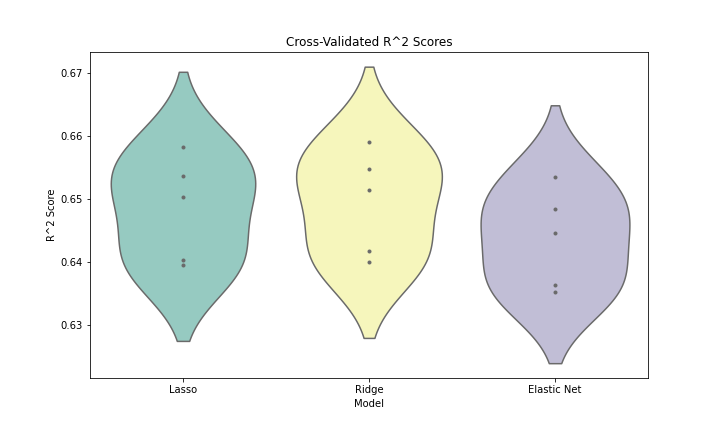
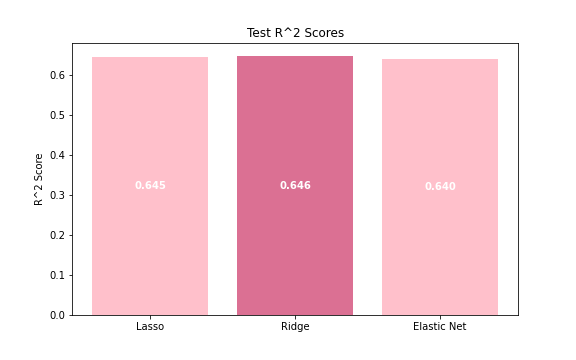

- It can be infered that Ridge Regression was slightly better on generalizing on test data with a R^2 score of 0.646. Therefore, it can be said that Ridge Regression is a best model in this case.

## <span style="color:maroon">5. Results and Interpretation</span> 

### **Results**

1. **Mean Squared Error (MSE):**
   - **Linear and Ridge Models:** Both the Linear and Ridge models have the same MSE of 32.2561. This metric measures the average squared difference between predicted and actual values. A lower MSE indicates better model performance. In this case, the value is relatively high, suggesting that there is room for improvement in capturing the variance in the data.
   - **Lasso and Elasticnet Models:** The Lasso model has a slightly higher MSE (32.5619) compared to Linear and Ridge. The Elasticnet model falls in between. This implies that the Lasso regularization may not have significantly improved the model's performance, and the added penalty for feature selection might not have been necessary in this case.

2. **R-squared Score:**
   - **Linear and Ridge Models:** Both models have the same R-squared score of 0.6462. R-squared measures the proportion of the response variable's variance captured by the model. In this context, the models explain approximately 64.62% of the variance, indicating a moderate level of predictive power. 
   - **Lasso and Elasticnet Models:** These models have slightly lower R-squared scores (0.6428 and 0.6444, respectively), suggesting a slightly weaker fit compared to Linear and Ridge models.

3. **Root Mean Squared Error (RMSE):**
   - **Linear, Ridge, and Elasticnet Models:** All three models have the same RMSE of 5.6794. This metric provides a similar interpretation to MSE but in the original units of the target variable. The relatively high RMSE indicates that there might be significant deviations between predicted and actual temperatures.
   - **Lasso Model:** The Lasso model has a slightly higher RMSE (5.7063), indicating a slightly larger average deviation from the actual temperatures.

### **Statistical Significance:**
- Chi-square test has been performed for Precip Type and Summary columns resulting in a Chi2 Statistic of 9022.713343478255 and P-value of 0. Since the p value is 0, Rejected Null Hypothesis and concluded that Precip Type and Summary are not independent
- The similarity in performance metrics between Linear and Ridge models suggests that regularization (L2 regularization in Ridge) might not have significantly impacted the model's performance in this case.
- The differences in MSE and R-squared scores for Lasso and Elasticnet compared to Linear and Ridge models are relatively small, indicating that the added complexity of Lasso and Elasticnet may not be justified.

### **Implications in the Context of Temperature Prediction:**
- The moderate R-squared score indicates that the models capture a substantial portion of the temperature variance, but there is still room for improvement.
- The relatively high MSE and RMSE values suggest that the models might struggle to accurately predict temperature, and there may be unaccounted factors contributing to the variability in the data.
- Further model refinement, feature engineering, or exploration of more sophisticated modeling techniques may be beneficial to enhance temperature prediction accuracy.

In summary, The models provided a better level of predictive power, there is room for improvement in capturing the intricacies of temperature prediction and hence additional approaches like Grid Search has been implemented to get better results. However, there hasn't been any significant changes in the performance of model.

### **Interpreting Model Coefficients**
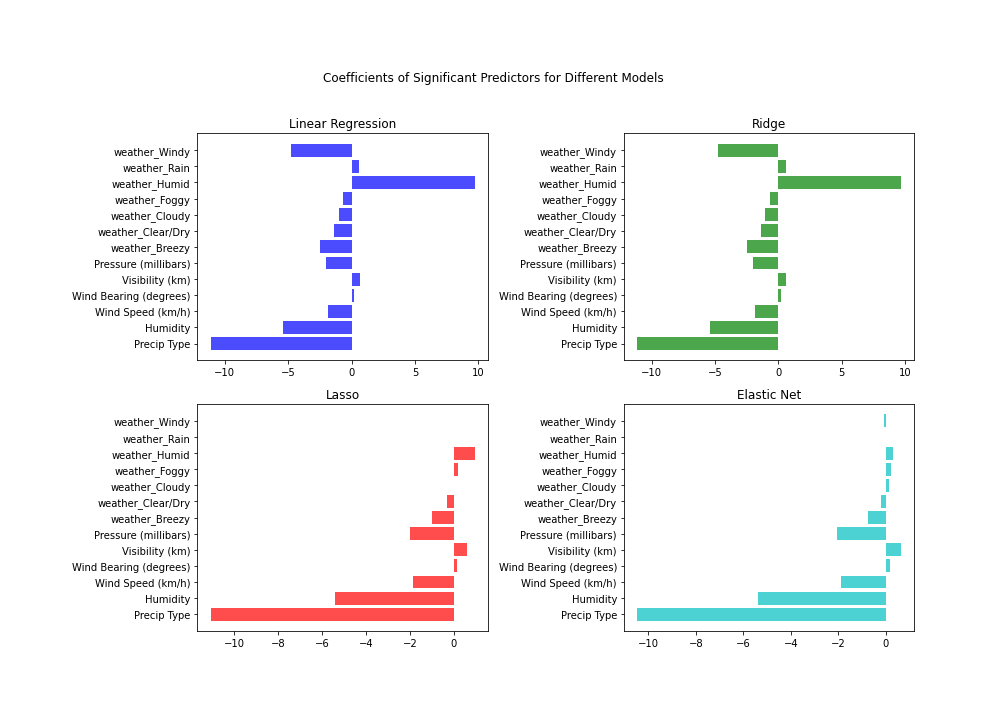

### **Linear and Ridge Regression:**

The Linear Regression and Ridge Regression models exhibit strikingly similar trends in the coefficients, suggesting a shared understanding of the data. Notably, the feature "Precip Type" stands out as a significant contributor, demonstrating a strong negative correlation with temperature. This implies that an increase in the precipitation type is associated with a decrease in temperature, and vice versa. This consistent observation reinforces the robustness of the relationship between Precip Type and temperature in both models.

Additionally, features such as Humidity and Windy conditions emerge as influential factors positively affecting temperature. The positive coefficients for these variables indicate that higher humidity levels and windy conditions are associated with an increase in temperature. These findings align with meteorological expectations and contribute to a more comprehensive understanding of the interplay between weather features and temperature.

### **Lasso and Elastic net Regression:**

In contrast, the Lasso Regression model introduces a dimension of feature selection by driving certain coefficients, such as Windy, Rain, and Cloudy conditions, to zero. This implies that, according to the Lasso model, these features have limited significance in predicting temperature. The regularization effect of Lasso encourages sparsity in the model, effectively excluding less impactful variables and simplifying the overall predictive framework. 

### **Overall Insights:**

Collectively, the analyses across these regression models offer a nuanced perspective on the intricate relationships within the dataset. While Precip Type consistently emerges as a powerful indicator of temperature, the differentiation between models sheds light on the nuanced importance of other features. Humidity and Windy conditions, for instance, consistently contribute positively to temperature predictions, reinforcing their meteorological significance.

The synthesis of these findings provides a refined understanding of the complex dynamics governing temperature variations and enhances the predictive capabilities of the regression models in capturing real-world weather patterns.

## <span style="color:maroon">6. Conclusion</span> 

The objectives initialized above during the start of the project were 
Analysis of weather data

- Hypothesis: The weather data will exhibit seasonal variations, and certain weather conditions will strongly correlate with temperature changes.

Developing regression models

- Hypothesis:  Multiple linear regression models can effectively capture the relationships between weather variables 
and temperature.

Evaluating Model Performance

- Hypothesis: The chosen regression model will demonstrate good performance metrics such as low Mean Squared Error and high R-squared.

Comparitive analysis between various regression models

- Hypothesis: Regularized regression models (e.g., Ridge, Lasso) will outperform basic linear regression due to their ability to handle multicollinearity.

Model Interpretability - Understanding key variables influencing temperature

- Hypothesis:  Certain weather features such as humidity, wind speed, and precipitation type will have a substantial impact on temperature, influencing the overall model interpretability.

The conclusion for each of the objective and the relative hypothesis is provided below.

### 1. Analysis of Weather Data:

- The initial hypothesis is that the weather data will exhibit seasonal variations, and certain weather conditions will strongly correlate with temperature changes.

- Explored and preprocessed weather data to ensure quality input for regression models.
- Utilized histograms for numerical features to understand their distributions, providing insights into the data spread.
- Employed violin plots to visualize temperature distributions based on precipitation types (rain/snow).
- Generated pair plots to visualize relationships between the dependent variable (Temperature) and independent variables.
- Identified linear trends and patterns, aiding in feature selection and understanding potential correlations.
- Utilized correlation matrices to quantify relationships between numerical features and temperature. Highlighted significant correlations, guiding feature selection and model development.
- Created bar charts to explore categorical data "Summary" enhancing understanding of weather conditions. Transformed the "Summary" column into distinct categories for improved data quality.
- To conclude on the hypothesis, it was observed that snow conditions influenced temperature to go to negative and rain conditions had temperatures above zero, so the hypothesis is true.


### 2. Developing Regression Models:

- Implemented Multiple Linear Regression as the baseline model, assuming a linear relationship.
- Utilized Ridge Regression to address multicollinearity and Lasso Regression for feature selection.
- Employed Elastic Net Regression for a balanced approach combining Ridge and Lasso techniques.
- Multiple Linear Regression and Ridge Regression had the lowest Mean Squared Error and highest R^2 scores which aligns with our hypothesis that Multiple linear regression models can effectively capture the relationships between weather variables and temperature.

### 3. Evaluating Model Performance:

- Evaluated models using Mean Squared Error, R-squared Score, and Root Mean Squared Error.
- Conducted cross-validation for robust performance assessment.
- Assessed models using key metrics and cross-validation for robust performance evaluation.
- The initial best model chosen was Linear Regression and it had a similar results with Ridge Regression, so this aligns with the hypothesis that the chosen regression model will demonstrate good performance metrics such as low Mean Squared Error and high R-squared.

### 4. Comparative Analysis Between Various Regression Models:

- Compared Linear, Ridge, Lasso, and Elastic Net models, identifying slight performance variations.
- Visualized cross-validated R-squared scores and test R-squared scores.
- Compared model performance, identifying Ridge Regression as slightly superior.
- After performing regualarization, feature selection, Ridge regression is the model that had better R^2 scores and less MSE scores. This aligns with the hypothesis that regularized regression models (e.g., Ridge, Lasso) will outperform basic linear regression due to their ability to handle multicollinearity.

### 5. Model Interpretability:
- The initial hypothesis is that certain weather features such as humidity, wind speed, and precipitation type will have a substantial impact on temperature, influencing the overall model interpretability. 
- Analyzed coefficients to interpret the impact of weather features on temperature.
- Identified Precip Type, Humidity, and Windy conditions as consistent influencers.
- Emphasized Lasso Regression for effective feature selection.
- Successfully identified key variables influencing temperature variations.
- From the above analysis, it is observed that Precip Type, Humidity, and Windy conditions as consistent influencers which aligns with our initial hypothesis.


**The selected models were efficient in predicting the temperature.**

### Limitations:
One significant limitation of this analysis lies in the temporal scope of the dataset, covering the years 2006 to 2016. While offering valuable insights, this timeframe might not fully encapsulate the dynamic, long-term trends, or cyclic patterns inherent in weather data. The imputation of missing data, particularly in the "Precip Type" column, relied on a straightforward method of filling missing values with the mode. Employing more sophisticated imputation techniques or predictive modeling could enhance the accuracy of imputed data. The handling of outliers through the Interquartile Range (IQR) method, while effective, may result in the exclusion of potentially relevant data points. Exploring more nuanced outlier detection strategies could address this limitation. Additionally, though the models used proved effective, they may have constraints in capturing intricate relationships within meteorological data.

### Future Goals:
Moving forward, an essential future goal is to extend the dataset into more recent years, providing a current and comprehensive understanding of evolving weather patterns. Exploring advanced feature engineering, such as incorporating additional weather features or derived variables, could contribute to a more nuanced representation of weather conditions. The integration of spatial data to account for regional variations in weather patterns is another avenue for improvement. Implementing ensemble learning techniques, which combine the strengths of multiple models, could potentially enhance overall predictive performance. Conducting a more thorough hyperparameter tuning process to fine-tune model configurations and improve predictive accuracy is also a key future goal. Additionally, developing a system that integrates real-time weather data would enhance the models' adaptability to current conditions, making predictions more relevant and accurate. Considering external factors like socio-economic data, geographical features, or climate change indicators could provide a broader context for temperature predictions. Improving model interpretability by employing model-agnostic interpretability techniques is another targeted goal, allowing stakeholders to understand the models' decisions more transparently.

## <span style="color:maroon">7. Reference and Appendix</span> 

### **References**:

https://pandas.pydata.org/docs/reference/frame.html

https://seaborn.pydata.org/api.html

https://matplotlib.org/stable/gallery/index.html

https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15

https://www.kaggle.com/datasets/prachi13/employeeattritionrate?resource=download

https://www.analyticsvidhya.com/blog/2022/01/different-types-of-regression-models/

https://www.analyticsvidhya.com/blog/2021/05/know-the-best-evaluation-metrics-for-your-regression-model/

### **Appendix**: 

```python
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")‘‘‘

#Loading the data
weather_data = pd.read_csv("weatherHistory.csv")

#Dimensions of the data
print("No.of rows in the data:",weather_data.shape[0])
print("No.of columns in the data:",weather_data.shape[1])

weather_data.head()
weather_data.info()
weather_data.describe()
weather_data[['Summary','Precip Type','Daily Summary']].describe()
weather_data = weather_data.drop(columns=['Loud Cover'])

weather_data.isnull().sum()
weather_data['Precip Type'].value_counts()
weather_data['Precip Type'] = weather_data['Precip Type'].fillna('rain')
weather_data['Precip Type'].value_counts()
weather_data.isnull().sum()

quantitative_columns = [ 'Temperature (C)', 'Apparent Temperature (C)',
                        'Humidity', 'Wind Speed (km/h)','Wind Bearing (degrees)',
                        'Visibility (km)', 'Pressure (millibars)']
qualitative_coulmns = ['Formatted Date', 'Precip Type','Summary','Daily Summary']

weather_data.plot(kind='box', subplots=True, grid = True, sharey=False,
                  flierprops=dict(marker='o', markerfacecolor='red', markersize=8),
                  figsize=(26, 8))
plt.show()

It can be observed that except Wind Bearing(degrees) and Visibility(km) all the columns have outliers. Wind Speed(km/h) has highest number of outliers.

outlier_counts = {}

for column in quantitative_columns:
    q1 = weather_data[column].quantile(0.25)
    q3 = weather_data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = weather_data[(weather_data[column] < lower_bound) | (weather_data[column] > upper_bound)][column]
    outlier_counts[column] = len(outliers)
    weather_data[column] = weather_data[column].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if     x > upper_bound else x))

print("Outlier Counts for Each Column:\n")
for column, count in outlier_counts.items():
    print(f"{column}: {count}")

weather_data.plot(kind='box', subplots=True, grid = True, sharey=False,
                  flierprops=dict(marker='o', markerfacecolor='red', markersize=8),
                  figsize=(26, 8))
plt.show()

sns.heatmap(weather_data.corr(),annot = True,cmap="coolwarm")
plt.savefig('correlation-1.png',bbox_inches='tight')
plt.show()

weather_data = weather_data.drop(columns=['Apparent Temperature (C)'])

weather_data[qualitative_coulmns].head()

weather_data['Precip Type'].value_counts()

weather_data['Summary'].value_counts()

weather_data['Summary'] = weather_data['Summary'].replace({
    'Partly Cloudy': 'Cloudy',
    'Mostly Cloudy': 'Cloudy',
    'Overcast': 'Cloudy',
    'Clear': 'Clear/Dry',
    'Foggy': 'Foggy',
    'Breezy and Overcast': 'Breezy',
    'Breezy and Mostly Cloudy': 'Breezy',
    'Breezy and Partly Cloudy': 'Breezy',
    'Dry and Partly Cloudy': 'Clear/Dry',
    'Windy and Partly Cloudy': 'Windy',
    'Light Rain': 'Rain',
    'Breezy': 'Breezy',
    'Windy and Overcast': 'Windy',
    'Humid and Mostly Cloudy': 'Humid',
    'Drizzle': 'Rain',
    'Breezy and Foggy': 'Breezy',
    'Windy and Mostly Cloudy': 'Windy',
    'Dry': 'Clear/Dry',
    'Humid and Partly Cloudy': 'Humid',
    'Dry and Mostly Cloudy': 'Clear/Dry',
    'Rain': 'Rain',
    'Windy': 'Windy',
    'Humid and Overcast': 'Humid',
    'Windy and Foggy': 'Windy',
    'Windy and Dry': 'Windy',
    'Dangerously Windy and Partly Cloudy': 'Windy',
    'Breezy and Dry': 'Breezy'
})

weather_data['Summary'].value_counts()

weather_data['Daily Summary'].value_counts()

weather_data = weather_data.drop(columns=['Daily Summary'])

weather_data['Precip Type'] = weather_data['Precip Type'].replace({'rain':0,'snow':1})

weather_data['Precip Type'].value_counts()

weather_data_encoded = pd.get_dummies(weather_data['Summary'], prefix='weather')

weather_data_encoded.head()

columns_to_normalize = ['Humidity','Wind Speed (km/h)','Wind Bearing (degrees)',
                                'Visibility (km)', 'Pressure (millibars)']
weather_data_new = weather_data[columns_to_normalize]
weather_data_new.head()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
standardized_data = scaler.fit_transform(weather_data_new)
weather_data_standardized = pd.DataFrame(standardized_data, columns=columns_to_normalize)
weather_data_new[columns_to_normalize] = weather_data_standardized
weather_data_new.head()

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(weather_data['Precip Type'], weather_data['Summary'])

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2 Statistic: {chi2_stat}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("Rejected Null Hypothesis;Precip Type and Summary are not independent")
else:
     print("Accepted Null Hypothesis;Precip Type and Summary are independent")


weather_data = weather_data.drop(columns=['Formatted Date','Summary','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)'
                                         ,'Visibility (km)','Pressure (millibars)'])

weather_data_updated = pd.concat([weather_data,weather_data_new,weather_data_encoded], axis=1)
weather_data_updated.head()

weather_data_updated.shape

weather_data_updated.info()

quantitative_columns = [ 'Temperature (C)',
                        'Humidity', 'Wind Speed (km/h)','Wind Bearing (degrees)',
                        'Visibility (km)', 'Pressure (millibars)']
weather_data_updated[quantitative_columns].hist(bins=50, figsize=(20,15))
plt.savefig('histograms.png')

#Histograms for all numerical features
fig, axs = plt.subplots(2, 3, figsize=(15, 5))
i,j = 0,0

for c in weather_data_updated[quantitative_columns]:
    sns.histplot(data=weather_data_updated, x=c, kde=True, ax=axs[i,j])
    j += 1
    if j == 3:
        j = 0
        i += 1
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.4)
plt.show()

sns.heatmap(weather_data_updated[quantitative_columns].corr(),annot = True,cmap="coolwarm")
plt.show()

#Pairplot between Independent features and dependent feature
plt.figure(figsize=(12, 8))
sns.pairplot(weather_data_updated,x_vars = ['Humidity', 'Wind Speed (km/h)','Wind Bearing (degrees)',
                        'Visibility (km)', 'Pressure (millibars)'],y_vars=['Temperature (C)'],kind='reg',height=7, 
             plot_kws={'line_kws': {'color': 'red'}})
plt.savefig('pairplot.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(x='Precip Type', y='Temperature (C)', data=weather_data_updated)
plt.title('Violin Plot of Temperature Distribution by Precip Type')
plt.savefig('violin-precip.png')
plt.show()

weather_conditions = weather_data_updated[['weather_Breezy', 'weather_Clear/Dry', 'weather_Cloudy',
                            'weather_Foggy', 'weather_Humid', 'weather_Rain', 'weather_Windy']].sum()
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=weather_conditions.index, y=weather_conditions.values)
plt.title('Bar Plot of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
for index, value in enumerate(weather_conditions):
    bar_plot.text(index, value + 0.1, str(value), ha='center', va='bottom')
plt.savefig('weather-conditions.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(weather_data_updated['Precip Type'])
plt.title("Count of Precip Type - Rain(0) and Snow(1)")
plt.show()

X = weather_data_updated.drop('Temperature (C)', axis=1)  # Independent variables
y = weather_data_updated['Temperature (C)']   

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,
                                                    random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet,RidgeCV
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_linear  = lr.predict(X_test)

y_pred = lr.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Check for Linearity')
plt.savefig('linearity.png')
plt.show()

from statsmodels.stats.stattools import durbin_watson

durbinWatson = durbin_watson(residuals)
print("Durbin-Watson:", durbinWatson)

y_pred = lr.predict(X)

residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Check for Homoscedasticity')
plt.savefig('Homoscedasticity.png')
plt.show()

import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.savefig('qqplot.png')
plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
  
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))]
  
print(vif_data)

from sklearn.metrics import mean_squared_error

mse_linear = mean_squared_error(y_test, y_pred_linear)

print("Mean Squared Error - Linear: ", mse_linear)

r2_score_linear = lr.score(X_test,y_test)

print("R-squared Score - Linear: ", r2_score_linear)

rmse_linear = np.sqrt(mse_linear)

print("RMSE - Linear: ", rmse_linear)

ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train,y_train)
y_pred_ridge=ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Mean Squared Error - Ridge: ", mse_ridge)

r2_score_ridge = ridge_model.score(X_test,y_test)

print("R-squared Score - Ridge: ", r2_score_ridge)

rmse_ridge = np.sqrt(mse_ridge)

print("RMSE - Ridge: ", rmse_ridge)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train,y_train)
y_pred_lasso=lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("Mean Squared Error - Lasso: ", mse_lasso)

r2_score_lasso  = lasso_model.score(X_test,y_test)

print("R-squared Score - Lasso: ", r2_score_lasso)

rmse_lasso = np.sqrt(mse_lasso)

print("RMSE - Lasso: ", rmse_lasso)

elasticnet_model = ElasticNet(alpha=0.01, l1_ratio=0.5)
elasticnet_model.fit(X_train,y_train)
y_pred_elasticnet = elasticnet_model.predict(X_test)

mse_elasticnet = mean_squared_error(y_test, y_pred_elasticnet)

print("Mean Squared Error - Elasticnet: ", mse_elasticnet)

r2_score_elasticnet  = elasticnet_model.score(X_test,y_test)

print("R-squared Score - Elasticnet: ", r2_score_elasticnet)

rmse_elasticnet = np.sqrt(mse_elasticnet)

print("RMSE - Elasticnet: ", rmse_elasticnet)

alphas = np.logspace(-4, 4, 200)
ridge_cv = RidgeCV(alphas=alphas)
ridge_cv.fit(X_train,y_train)
y_pred_ridgecv=ridge_cv.predict(X_test)

print('Ridge CV Model Mean Squared Error:', mean_squared_error(y_test,y_pred_ridgecv))
print('Best Alpha after Cross Validation :', ridge_cv.alpha_)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Coefficients of Significant Predictors for Different Models', y=1.02)

linear_coeffs = lr.coef_
ridge_coeffs = ridge_model.coef_
lasso_coeffs = lasso_model.coef_
elasticnet_coeffs = elasticnet_model.coef_

axes[0, 0].barh(X.columns, linear_coeffs, color='b', alpha=0.7)
axes[0, 0].set_title('Linear Regression')
axes[0, 1].barh(X.columns, ridge_coeffs, color='g', alpha=0.7)
axes[0, 1].set_title('Ridge')
axes[1, 0].barh(X.columns, lasso_coeffs, color='r', alpha=0.7)
axes[1, 0].set_title('Lasso')
axes[1, 1].barh(X.columns, elasticnet_coeffs, color='c', alpha=0.7)
axes[1, 1].set_title('Elastic Net')

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.savefig('coefficients_plot.png', bbox_inches='tight', pad_inches=1)
plt.show()

from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.model_selection import cross_val_score

sfm = SelectFromModel(ridge_model)
X_new = sfm.fit_transform(X, y)

scores = cross_val_score(ridge_model, X_new, y, cv=5)
print("Cross-validated R^2 scores:", scores.mean())

from sklearn.model_selection import GridSearchCV

lasso_params = {'alpha': [0.1, 0.5, 1.0], 'max_iter': [1000, 2000, 5000]}
ridge_params = {'alpha': [0.1, 0.5, 1.0], 'max_iter': [1000, 2000, 5000]}
elastic_net_params = {'alpha': [0.1, 0.5, 1.0], 'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [1000, 2000, 5000]}

lasso_grid_search = GridSearchCV(lasso_model, lasso_params, cv=5, scoring='r2')
ridge_grid_search = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2')
elastic_net_grid_search = GridSearchCV(elasticnet_model, elastic_net_params, cv=5, scoring='r2')

lasso_grid_search.fit(X_train, y_train)
ridge_grid_search.fit(X_train, y_train)
elastic_net_grid_search.fit(X_train, y_train)

print("Lasso Best Parameters:", lasso_grid_search.best_params_)
print("Lasso Test R^2 Score:", lasso_grid_search.best_estimator_.score(X_test, y_test))

print("Ridge Best Parameters:", ridge_grid_search.best_params_)
print("Ridge Test R^2 Score:", ridge_grid_search.best_estimator_.score(X_test, y_test))

print("Elastic Net Best Parameters:", elastic_net_grid_search.best_params_)
print("Elastic Net Test R^2 Score:", elastic_net_grid_search.best_estimator_.score(X_test, y_test))

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.model_selection import cross_val_score

lasso_model = LassoCV(cv=5)
ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
elastic_net_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=[0.1, 1.0, 10.0], cv=5)

lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
elastic_net_model.fit(X_train, y_train)

cv_scores = {
    'Lasso': cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='r2'),
    'Ridge': cross_val_score(ridge_model, X_train, y_train, cv=5, scoring='r2'),
    'Elastic Net': cross_val_score(elastic_net_model, X_train, y_train, cv=5, scoring='r2')
}

print("Selected Alpha (Lasso):", lasso_model.alpha_)
print("Selected Alpha (Ridge):", ridge_model.alpha_)
print("Selected Alpha (Elastic Net):", elastic_net_model.alpha_)
print("Selected L1 Ratio (Elastic Net):", elastic_net_model.l1_ratio_)

for model, scores in cv_scores.items():
    print(f"Cross-validated R^2 scores ({model}): {scores.mean()}")

lasso_test_score = lasso_model.score(X_test, y_test)
ridge_test_score = ridge_model.score(X_test, y_test)
elastic_net_test_score = elastic_net_model.score(X_test, y_test)

print("Test R^2 Score (Lasso):", lasso_test_score)
print("Test R^2 Score (Ridge):", ridge_test_score)
print("Test R^2 Score (Elastic Net):", elastic_net_test_score)

plt.figure(figsize=(10, 6))
sns.violinplot(data=list(cv_scores.values()),inner="points", palette="Set3")
plt.xticks(range(len(cv_scores)), list(cv_scores.keys()))
plt.title('Cross-Validated R^2 Scores')
plt.xlabel('Model')
plt.ylabel('R^2 Score')
plt.savefig('Cross-Validated.png')
plt.show()

test_scores = [lasso_test_score, ridge_test_score, elastic_net_test_score]

plt.figure(figsize=(8, 5))
bars = plt.bar(['Lasso', 'Ridge', 'Elastic Net'], test_scores, color=['pink', 'palevioletred', 'pink'])

for bar, score in zip(bars, test_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{score:.3f}', ha='center', va='center', color='white', fontweight='bold')
plt.title('Test R^2 Scores')
plt.ylabel('R^2 Score')
plt.savefig('R^2-scores.png')
plt.show()
```